# Isovalue Specialist: Histogram Bands + Derived Opacity Ramp

Tests `visualization_orchestrator/specialists/isovalue_adapter.py` directly -- no planner, no camera specialist, no `VisualizationOrchestrator` wrapper -- so you can inspect each step in isolation:

1. `compute_histogram_bands` -- segment the volume's intensity histogram into material bands (deterministic).
2. Render one cheap preview per band, under that band's own derived opacity ramp (deterministic).
3. `run_isovalue_band_selection` -- one LLM call picks which band matches a goal, then deterministically derives and applies an opacity ramp from that band's own range.
4. If the LLM reports the selected band still looks like a mix of materials, ONE bounded refinement round splits it into sub-ranges and repeats steps 2-3 among just those.

Some datasets (e.g. `data/skull_256x256x256_uint8.raw`, `data/foot_256x256x256_uint8.raw`) have no distinct bone peak in their histogram at all -- bone blends continuously into soft tissue as a smooth gradient rather than forming its own population of voxels. Step 4 exists specifically for that case: see the README's "Isovalue specialist" section for the full mechanism.

## Setup

Scene initialized. Isovalue=40, dims=(256, 256, 256).


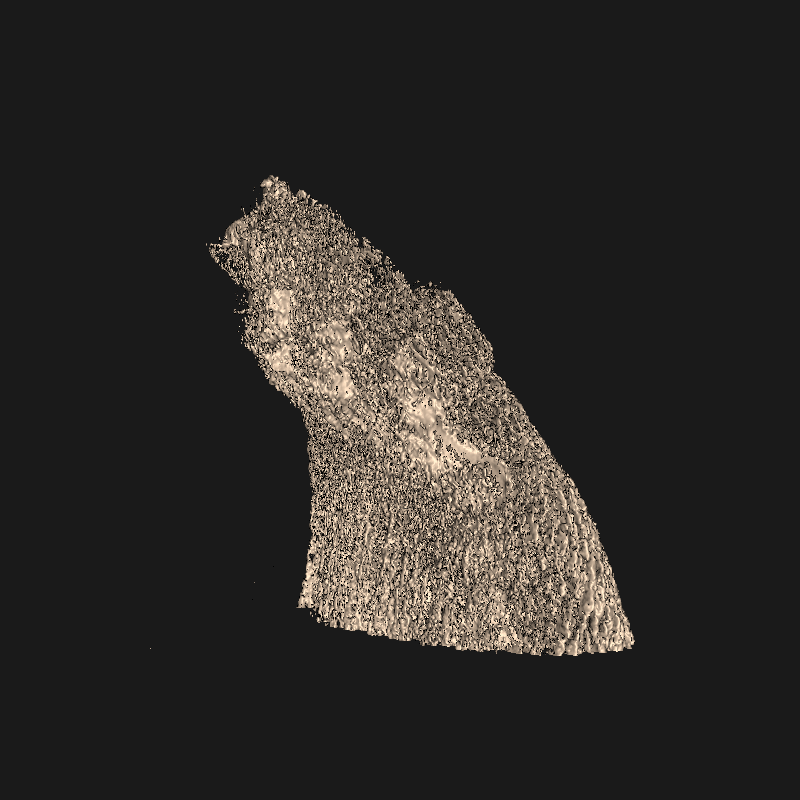

In [10]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

from IPython.display import Image, display
import matplotlib.pyplot as plt
import numpy as np

from camera_reasoning.session import CameraReasoningSession
from visualization_orchestrator.specialists.isovalue_adapter import (
    BAND_LABEL_PREFIX,
    build_opacity_ramp_for_band,
    compute_histogram_bands,
    render_band_previews,
    run_isovalue_band_selection,
)

DATASET_PATH = "../data/foot_256x256x256_uint8.raw"
DIMENSIONS = (256, 256, 256)

session = CameraReasoningSession(
    raw_path=DATASET_PATH,
    dimensions=DIMENSIONS,
    isovalue=40,
    output_dir="../output/isovalue_band_demo",
)
session.initialize()
display(Image(filename=session.render_and_save()))

## Step 1: histogram bands (deterministic, no LLM)

Each band is a `[low, high)` intensity range with one `peak`. `voxel_fraction` is how much of the volume falls in that band -- should sum to ~1.0.

In [11]:
bands = compute_histogram_bands(DATASET_PATH)
for b in bands:
    print(f"[{b['low']:3d}-{b['high']:3d})  peak={b['peak']:3d}  voxel_fraction={b['voxel_fraction']:.4f}")
print(f"total voxel_fraction: {sum(b['voxel_fraction'] for b in bands):.6f}")

[  0-  6)  peak=  4  voxel_fraction=0.7208
[  6-256)  peak= 32  voxel_fraction=0.2792
total voxel_fraction: 1.000000


### Visualize the histogram with band boundaries overlaid

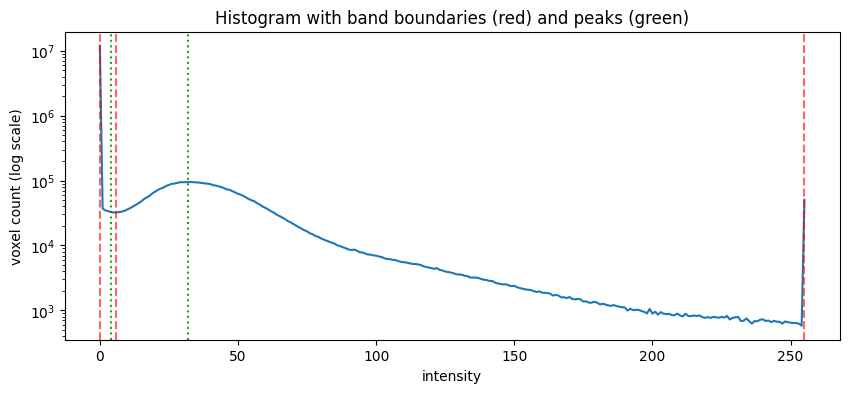

In [3]:
intensities = np.fromfile(DATASET_PATH, dtype=np.uint8)
hist, edges = np.histogram(intensities, bins=256, range=(0, 256))

plt.figure(figsize=(10, 4))
plt.plot(hist)
for b in bands:
    plt.axvline(b["low"], color="red", linestyle="--", alpha=0.6)
    plt.axvline(b["peak"], color="green", linestyle=":", alpha=0.8)
plt.axvline(bands[-1]["high"] - 1, color="red", linestyle="--", alpha=0.6)
plt.yscale("log")
plt.xlabel("intensity")
plt.ylabel("voxel count (log scale)")
plt.title("Histogram with band boundaries (red) and peaks (green)")
plt.show()

## Step 2: per-band preview renders (deterministic, no LLM)

One preview per band, rendered under THAT band's own derived opacity ramp via direct volume rendering -- the same rendering `build_opacity_ramp_for_band` produces for the final applied result, not a single isosurface at the band's peak (a peak can sit nowhere near where a broad/lopsided band's real material shows up, so an isosurface there would be a poor stand-in for the band as a whole). This is what the LLM is shown when picking a band. `multi_angle=False` here just to keep this cheap/fast; the real pipeline defaults to a 6-angle tiled grid per band.

BAND_0_6  (opacity ramp peak=4)


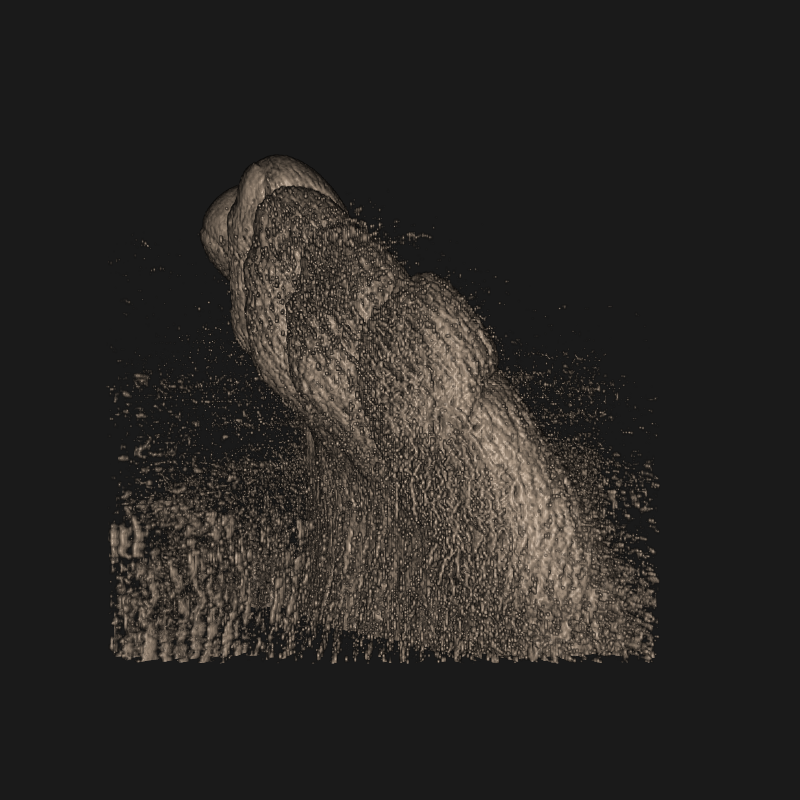

BAND_6_256  (opacity ramp peak=32)


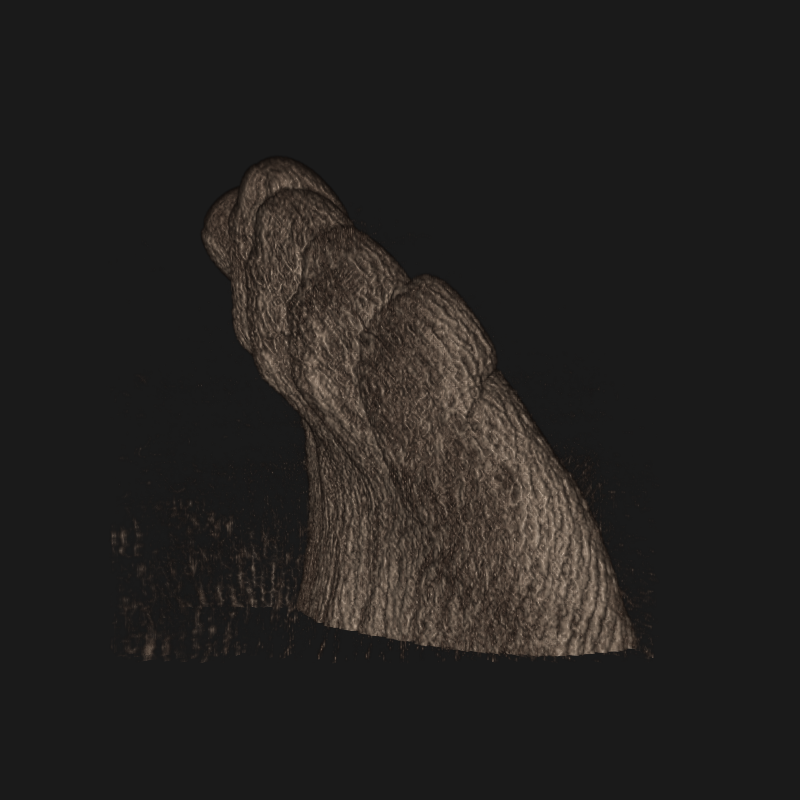

In [12]:
previews = render_band_previews(session, bands, "../output/isovalue_band_demo/previews", multi_angle=False)

for band, path in previews:
    print(f"{BAND_LABEL_PREFIX}{band['low']}_{band['high']}  (opacity ramp peak={band['peak']})")
    display(Image(filename=path, width=300))


## Step 3: full band selection (ONE real LLM call)

Requires `OPENAI_API_KEY`. Edit `GOAL` below and re-run to try different instructions -- e.g. `"show the bone"`, `"show the soft tissue"`, `"reduce the noise"`.

selected_band_label: BAND_6_256
converged: True
reasoning: BAND_6_256 is the best match for the goal of showing bone structure. While both bands display the bone anatomy, BAND_6_256 presents a much cleaner visualization with minimal noise and fragmentation compared to BAND_0_6, which exhibits significant speckled artifacts throughout all viewing angles. BAND_6_256 shows the bone as a relatively uniform, well-isolated material with smooth continuous surfaces, satisfying both success criteria: bone structure is clearly visible and there is minimal noise or fragmentation.

  [BAND_0_6] satisfies_goal=False  Shows bone structure of what appears to be a foot with visible toes and metatarsals. The bone is clearly visible across all viewing angles, but there is significant noise and fragmentation visible, particularly noticeable as speckled artifacts around the main bone structure in all views.
  [BAND_6_256] satisfies_goal=True  Shows the same bone structure (foot) but with noticeably cleane

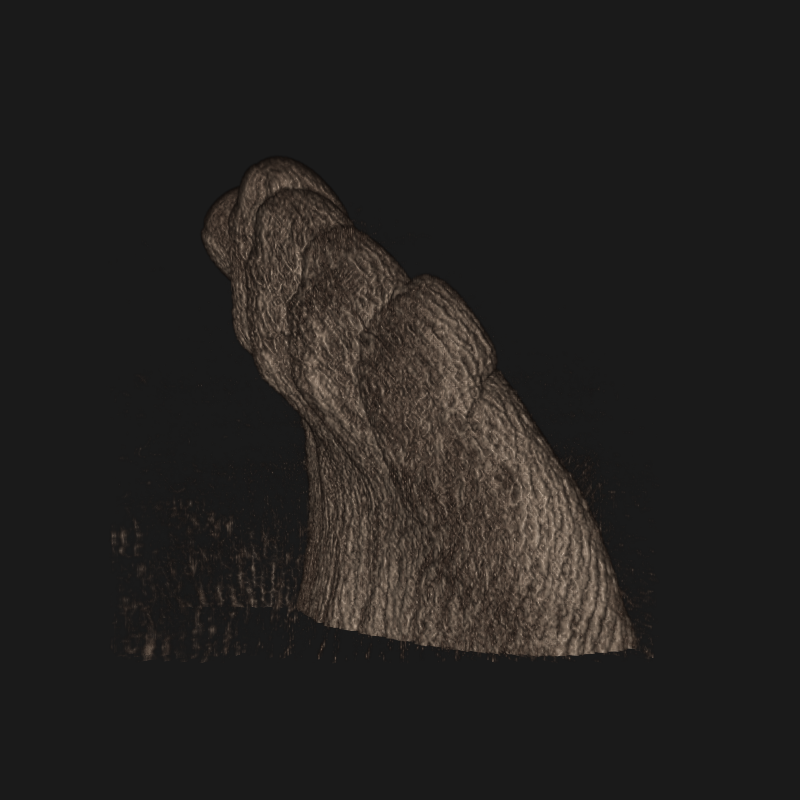

In [5]:
GOAL = "show the bone"
SUCCESS_CRITERIA = ["bone structure is clearly visible", "minimal noise or fragmentation"]

result = run_isovalue_band_selection(session, goal=GOAL, success_criteria=SUCCESS_CRITERIA)

print(f"selected_band_label: {result['selected_band_label']}")
print(f"converged: {result['converged']}")
print(f"reasoning: {result['reasoning']}")
print()
for entry in result["band_evaluation"]:
    print(f"  [{entry.get('band')}] satisfies_goal={entry.get('satisfies_goal')}  {entry.get('observation')}")

display(Image(filename=result["final_image_path"]))

## Step 4: inspect the derived opacity ramp (deterministic, no LLM)

The selected band's own `[low, high, peak]` -- not hand-tuned constants -- determine these control points. See `build_opacity_ramp_for_band` in `isovalue_adapter.py`.

opacity_points: [(0.0, 0.0), (6, 0.05), (32, 0.55), (256, 0.7)]
color_points: [(0.0, 0.0, 0.0, 0.0), (6, 0.35, 0.25, 0.2), (32, 0.85, 0.75, 0.65), (256.0, 0.85, 0.75, 0.65)]


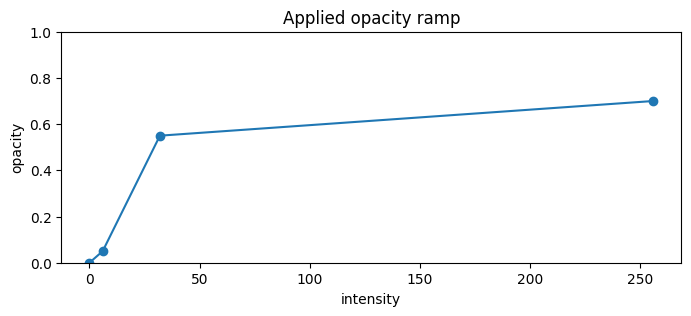

In [6]:
print("opacity_points:", result["final_opacity_points"])
print("color_points:", result["final_color_points"])

if result["final_opacity_points"]:
    xs, ys = zip(*result["final_opacity_points"])
    plt.figure(figsize=(8, 3))
    plt.plot(xs, ys, marker="o")
    plt.xlabel("intensity")
    plt.ylabel("opacity")
    plt.title("Applied opacity ramp")
    plt.ylim(0, 1)
    plt.show()

## Try a different band directly (no LLM, no goal -- just pick one from Step 1's list by index)

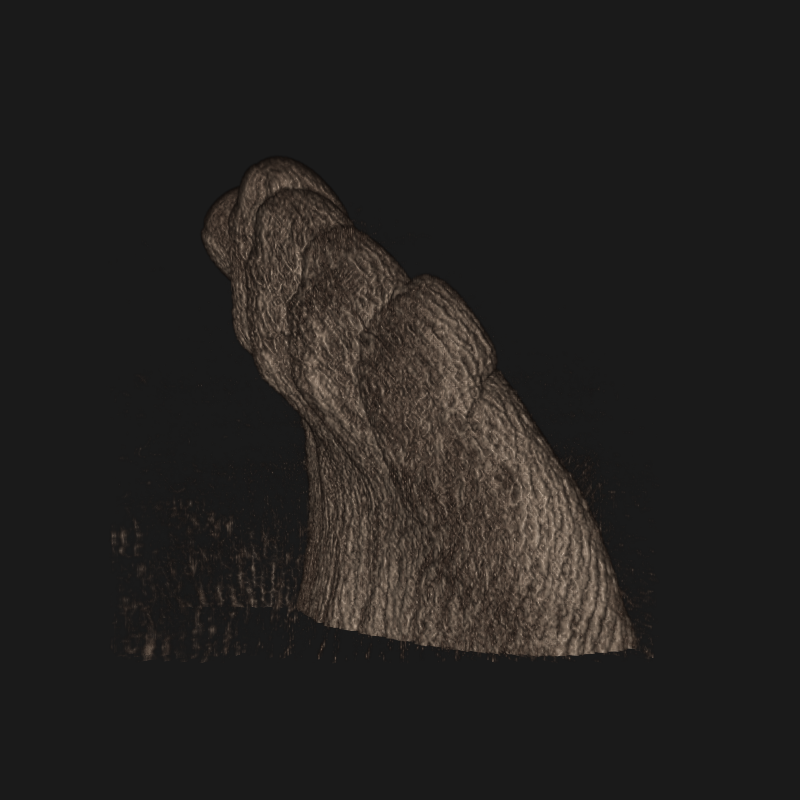

In [7]:
BAND_INDEX = 1  # 0=background, 1=soft tissue, 2=bone for vis_male's 3 bands

chosen_band = bands[BAND_INDEX]
opacity_points, color_points = build_opacity_ramp_for_band(chosen_band)
session.set_transfer_function(opacity_points, color_points)
display(Image(filename=session.render_and_save()))